In [1]:
# ============================================================
# SANAE Time Series by Southern Ocean Biome
# Variables:
#   - Salinity
#   - Temperature
#   - Total Carbon (CT)
#   - Total Alkalinity (AT)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# Load dataset
# ============================================================

file_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Combined_Underway_clean.xlsx"

df = pd.read_excel(file_path)


In [3]:
# ============================================================
# Convert date column
# ============================================================

df["Date"] = pd.to_datetime(df["Date"], errors='coerce')


/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_16505/4027716823.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Summer_Year"] = np.nan
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_16505/4027716823.py:148: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_16505/4027716823.py:156: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(output_figure, dpi=300, bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


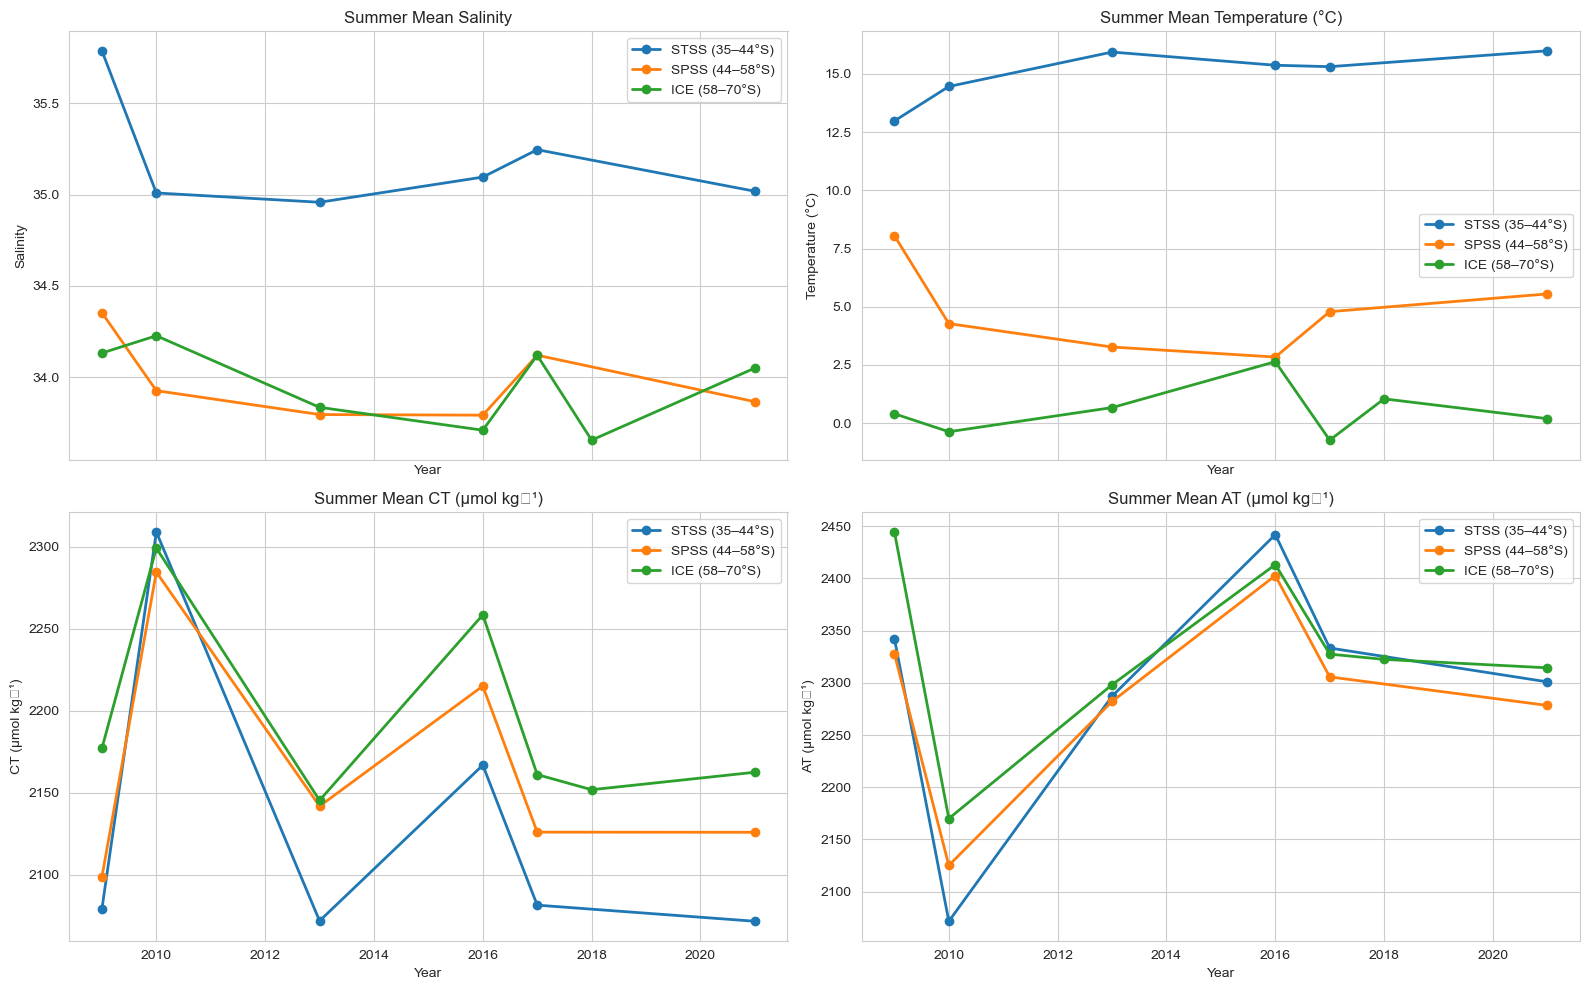

Figure saved successfully:
/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_TimeSeries_Biomes.png


In [5]:
# ============================================================
# Define biome assignment
# ============================================================

def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# ============================================================
# Define summers (Dec–Feb windows)
# ============================================================

summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# ============================================================
# Assign biome using latitude
# ============================================================

df["Biome"] = df["Lat"].apply(assign_biome)

# Keep only defined biomes
df = df[df["Biome"] != "Outside Defined Biome"]

# ============================================================
# Assign summer year
# ============================================================

df["Summer_Year"] = np.nan

for year, (start, end) in summer_ranges.items():

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    mask = (df["Date"] >= start) & (df["Date"] <= end)

    df.loc[mask, "Summer_Year"] = year

# Keep only summer observations
df = df.dropna(subset=["Summer_Year"])

# Convert to integer
df["Summer_Year"] = df["Summer_Year"].astype(int)

# ============================================================
# Remove missing values
# ============================================================

variables = [
    "Salinity",
    "Temperature",
    "Total Carbon",
    "Total Alkalinity"
]

df = df.dropna(subset=variables)

# ============================================================
# Compute annual biome means
# ============================================================

grouped = (
    df.groupby(["Summer_Year", "Biome"])[variables]
    .mean()
    .reset_index()
)

# ============================================================
# Plot settings
# ============================================================

sns.set_style("whitegrid")

plot_labels = {
    "Salinity": "Salinity",
    "Temperature": "Temperature (°C)",
    "Total Carbon": "CT (µmol kg⁻¹)",
    "Total Alkalinity": "AT (µmol kg⁻¹)"
}

biomes = [
    "STSS (35–44°S)",
    "SPSS (44–58°S)",
    "ICE (58–70°S)"
]

# ============================================================
# Create subplots
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
    sharex=True
)

axes = axes.flatten()

# ============================================================
# Plot each variable
# ============================================================

for ax, variable in zip(axes, variables):

    for biome in biomes:

        subset = grouped[grouped["Biome"] == biome]

        ax.plot(
            subset["Summer_Year"],
            subset[variable],
            marker='o',
            linewidth=2,
            label=biome
        )

    ax.set_title(f"Summer Mean {plot_labels[variable]}")
    ax.set_xlabel("Year")
    ax.set_ylabel(plot_labels[variable])

    ax.legend()

# ============================================================
# Final layout
# ============================================================

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================

output_figure = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_TimeSeries_Biomes.png"

plt.savefig(output_figure, dpi=300, bbox_inches='tight')

plt.show()

print("Figure saved successfully:")
print(output_figure)

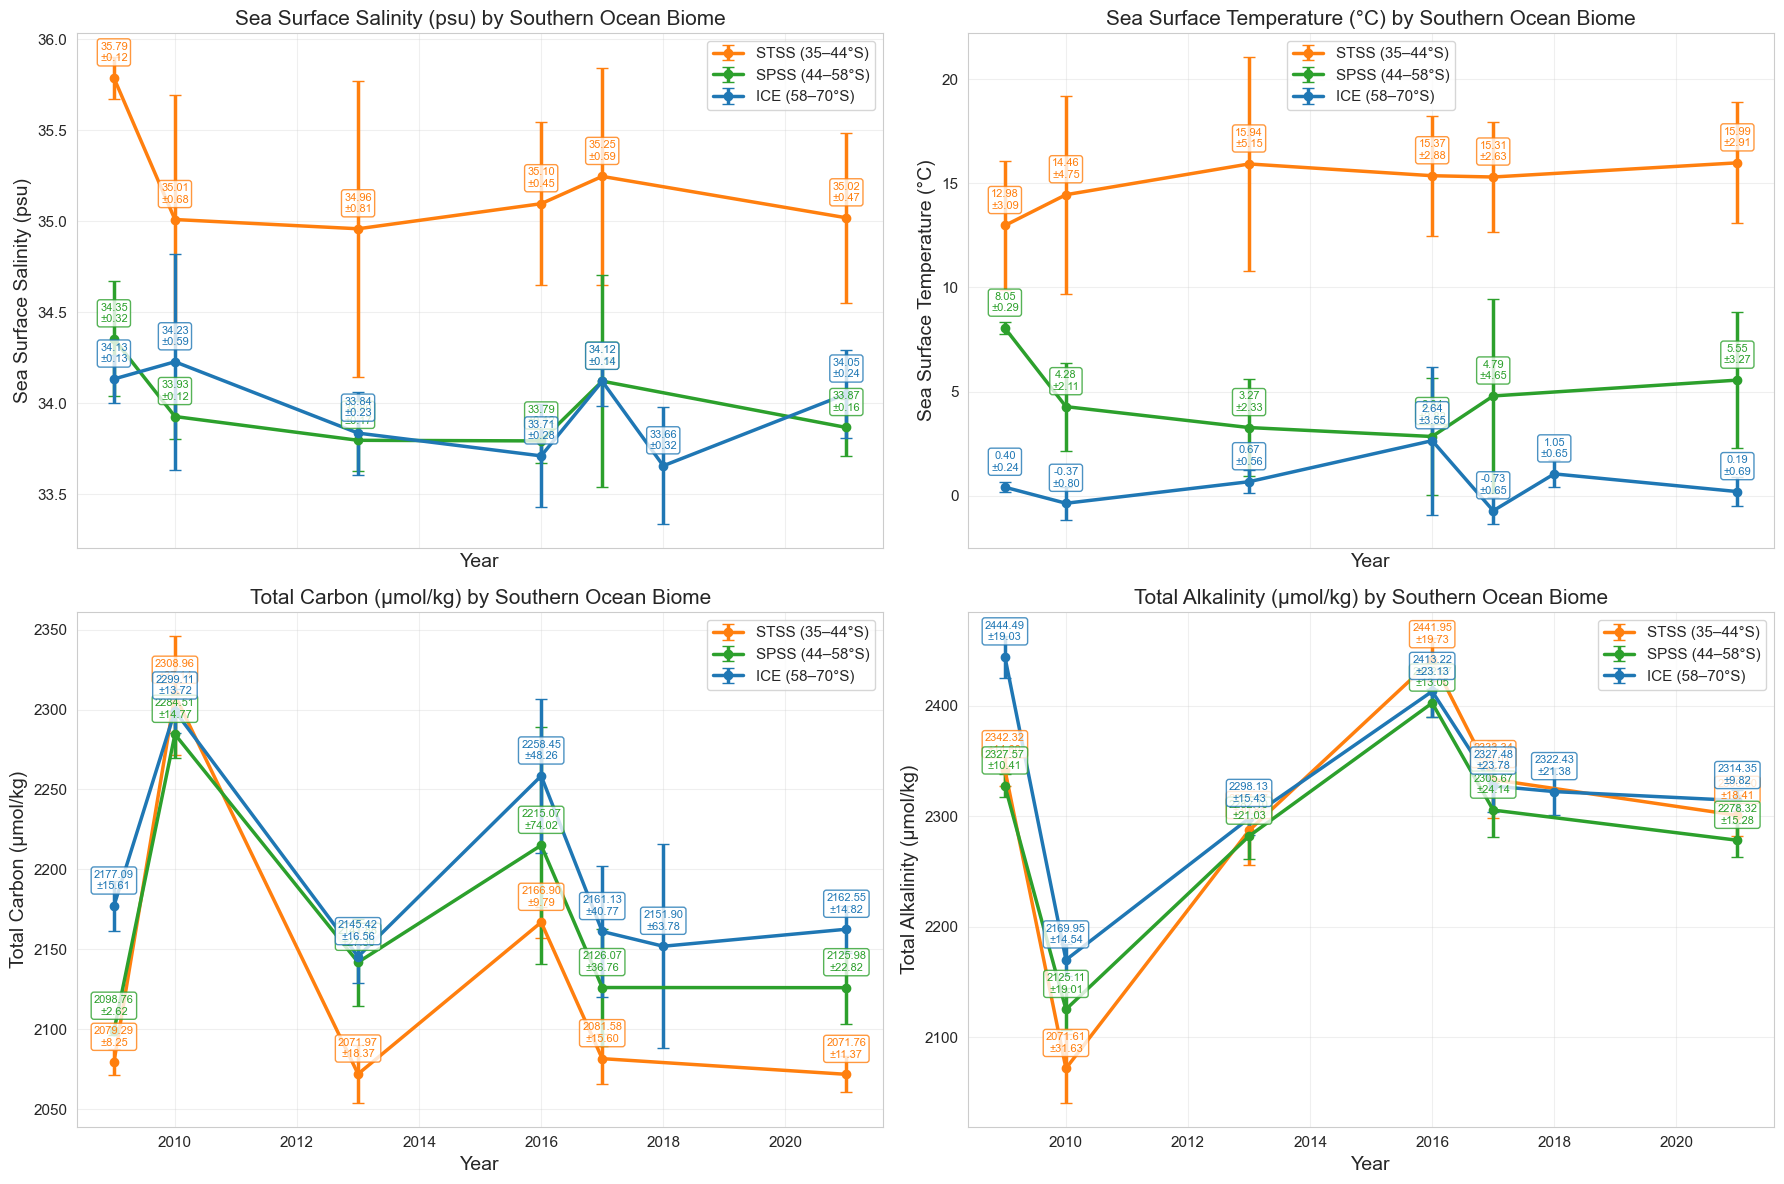

Publication-ready figure saved to:
/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Biome_TimeSeries_PublicationReady.png


In [7]:
# Convert date column
# ============================================================

df["Date"] = pd.to_datetime(df["Date"], errors='coerce')

# ============================================================
# Define biome assignment
# ============================================================

def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# ============================================================
# Define summer periods
# ============================================================

summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# ============================================================
# Assign biome
# ============================================================

df["Biome"] = df["Lat"].apply(assign_biome)

df = df[df["Biome"] != "Outside Defined Biome"]

# ============================================================
# Assign summer year
# ============================================================

df["Summer_Year"] = np.nan

for year, (start, end) in summer_ranges.items():

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    mask = (df["Date"] >= start) & (df["Date"] <= end)

    df.loc[mask, "Summer_Year"] = year

df = df.dropna(subset=["Summer_Year"])

df["Summer_Year"] = df["Summer_Year"].astype(int)

# ============================================================
# Variables
# ============================================================

variables = [
    "Salinity",
    "Temperature",
    "Total Carbon",
    "Total Alkalinity"
]

# Remove NaNs
df = df.dropna(subset=variables)

# ============================================================
# Compute mean and standard deviation
# ============================================================

stats = (
    df.groupby(["Summer_Year", "Biome"])[variables]
    .agg(['mean', 'std'])
)

# Flatten multi-index columns
stats.columns = ['_'.join(col) for col in stats.columns]

stats = stats.reset_index()

# ============================================================
# Plot settings
# ============================================================

sns.set_style("whitegrid")

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

# ============================================================
# Biome colours
# ============================================================

biome_colors = {
    'STSS (35–44°S)': '#ff7f0e',
    'SPSS (44–58°S)': '#2ca02c',
    'ICE (58–70°S)': '#1f77b4'
}

# ============================================================
# Axis labels
# ============================================================

ylabels = {
    "Salinity": "Sea Surface Salinity (psu)",
    "Temperature": "Sea Surface Temperature (°C)",
    "Total Carbon": "Total Carbon (µmol/kg)",
    "Total Alkalinity": "Total Alkalinity (µmol/kg)"
}

# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    sharex=True
)

axes = axes.flatten()

# ============================================================
# Plotting loop
# ============================================================

for ax, variable in zip(axes, variables):

    for biome, color in biome_colors.items():

        subset = stats[stats["Biome"] == biome]

        years = subset["Summer_Year"]

        means = subset[f"{variable}_mean"]

        stds = subset[f"{variable}_std"]

        # Plot means with standard deviation
        ax.errorbar(
            years,
            means,
            yerr=stds,
            fmt='-o',
            color=color,
            linewidth=2.5,
            markersize=6,
            capsize=4,
            label=biome
        )

        # ====================================================
        # Annotate mean ± std
        # ====================================================

        for x, y, s in zip(years, means, stds):

            label = f"{y:.2f}\n±{s:.2f}"

            ax.annotate(
                label,
                (x, y),
                textcoords="offset points",
                xytext=(0, 12),
                ha='center',
                fontsize=8,
                color=color,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc='white',
                    ec=color,
                    alpha=0.8
                )
            )

    # ========================================================
    # Axis formatting
    # ========================================================

    ax.set_ylabel(ylabels[variable])
    ax.set_xlabel("Year")

    ax.set_title(f"{ylabels[variable]} by Southern Ocean Biome")

    ax.grid(True, alpha=0.3)

    ax.legend(frameon=True)

# ============================================================
# Improve layout
# ============================================================

plt.tight_layout()

# ============================================================
# Save high-resolution figure
# ============================================================

output_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Biome_TimeSeries_PublicationReady.png"

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print("Publication-ready figure saved to:")
print(output_path)